In [1]:
from pathlib import Path

import torch
import torchaudio

from einops import rearrange

from e2_tts_pytorch import E2TTS, DurationPredictor

from vocos import Vocos

import matplotlib.pyplot as plt

/Users/lucasnewman/miniforge3/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
vocos = Vocos.from_pretrained("charactr/vocos-mel-24khz")

In [3]:
# duration_predictor = DurationPredictor(
#     transformer = dict(
#         dim = 100,
#         depth = 2,
#     ),
#     text_num_embeds = 256
# )

e2tts = E2TTS(
    # duration_predictor = duration_predictor,
    text_num_embeds = 80,
    cond_drop_prob = 0.0,
    char_embed_kwargs = dict(
        num_gateloop_layers = 0,
    ),
    transformer = dict(
        dim = 512,
        depth = 8,
        heads = 8,
        max_seq_len = 2048,
        num_gateloop_layers = 0,
        skip_connect_type = 'concat'
    ),
    mel_spec_kwargs = dict(
        filter_length = 1024,
        hop_length = 256,
        win_length = 1024,
        n_mel_channels = 100,
        sampling_rate = 24000,
    )
)

checkpoint = torch.load('e2tts.pt', map_location='cpu')
e2tts.load_state_dict(checkpoint['model_state_dict'])


<All keys matched successfully>

In [4]:
# from e2_tts_pytorch.trainer import TextAudioDataset

# train_dataset = TextAudioDataset(Path("~/data/LibriTTS_R/dev-clean").expanduser())

In [5]:


phone_to_token = {
    '!': 1,
    "'": 2,
    ',': 3,
    '-': 4,
    '.': 5,
    '..': 6,
    '...': 7,
    '?': 8,
    'AA0': 9,
    'AA1': 10,
    'AA2': 11,
    'AE0': 12,
    'AE1': 13,
    'AE2': 14,
    'AH0': 15,
    'AH1': 16,
    'AH2': 17,
    'AO0': 18,
    'AO1': 19,
    'AO2': 20,
    'AW0': 21,
    'AW1': 22,
    'AW2': 23,
    'AY0': 24,
    'AY1': 25,
    'AY2': 26,
    'B': 27,
    'CH': 28,
    'D': 29,
    'DH': 30,
    'EH0': 31,
    'EH1': 32,
    'EH2': 33,
    'ER0': 34,
    'ER1': 35,
    'ER2': 36,
    'EY0': 37,
    'EY1': 38,
    'EY2': 39,
    'F': 40,
    'G': 41,
    'HH': 42,
    'IH0': 43,
    'IH1': 44,
    'IH2': 45,
    'IY0': 46,
    'IY1': 47,
    'IY2': 48,
    'JH': 49,
    'K': 50,
    'L': 51,
    'M': 52,
    'N': 53,
    'NG': 54,
    'OW0': 55,
    'OW1': 56,
    'OW2': 57,
    'OY0': 58,
    'OY1': 59,
    'OY2': 60,
    'P': 61,
    'R': 62,
    'S': 63,
    'SH': 64,
    'T': 65,
    'TH': 66,
    'UH0': 67,
    'UH1': 68,
    'UH2': 69,
    'UW0': 70,
    'UW1': 71,
    'UW2': 72,
    'V': 73,
    'W': 74,
    'Y': 75,
    'Z': 76,
    'ZH': 77
}

def tokenize_phonemes(text):
    tokens = []
    
    for phone in text.split():
        if len(phone) > 0:
            tokens.append(phone_to_token[phone])
    
    return torch.LongTensor(tokens)


original_mel_spec: torch.Size([100, 312])
mel_spec: torch.Size([1, 156, 100]), lens: tensor([156])
text: Of these things, and such as these, they ask no questions.
tokens: tensor([[16, 73, 30, 47, 76, 66, 44, 54, 76,  3, 15, 53, 29, 63, 16, 28, 13, 76,
         30, 47, 76,  3, 30, 38, 13, 63, 50, 53, 56, 50, 74, 32, 63, 28, 15, 53,
         76,  5]])


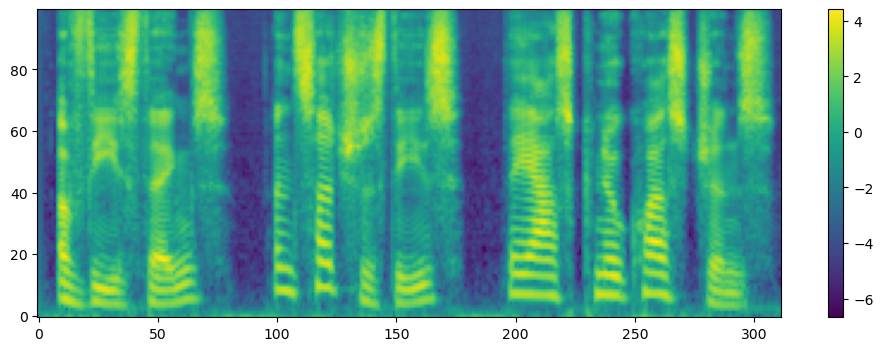

steps: 32, t: tensor([0.0000, 0.0323, 0.0645, 0.0968, 0.1290, 0.1613, 0.1935, 0.2258, 0.2581,
        0.2903, 0.3226, 0.3548, 0.3871, 0.4194, 0.4516, 0.4839, 0.5161, 0.5484,
        0.5806, 0.6129, 0.6452, 0.6774, 0.7097, 0.7419, 0.7742, 0.8065, 0.8387,
        0.8710, 0.9032, 0.9355, 0.9677, 1.0000]), text: tensor([[16, 73, 30, 47, 76, 66, 44, 54, 76,  3, 15, 53, 29, 63, 16, 28, 13, 76,
         30, 47, 76,  3, 30, 38, 13, 63, 50, 53, 56, 50, 74, 32, 63, 28, 15, 53,
         76,  5]]), cfg_strength: 0.0
predicting flow for time: 0.0
predicting flow for time: 0.016129031777381897
predicting flow for time: 0.032258063554763794
predicting flow for time: 0.04838709533214569
predicting flow for time: 0.06451612710952759
predicting flow for time: 0.08064515888690948
predicting flow for time: 0.09677419066429138
predicting flow for time: 0.11290322244167328
predicting flow for time: 0.12903225421905518
predicting flow for time: 0.14516128599643707
predicting flow for time: 0.1612903177738189

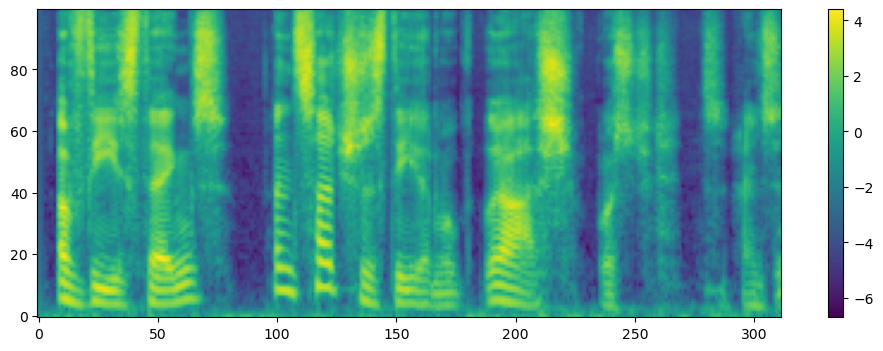

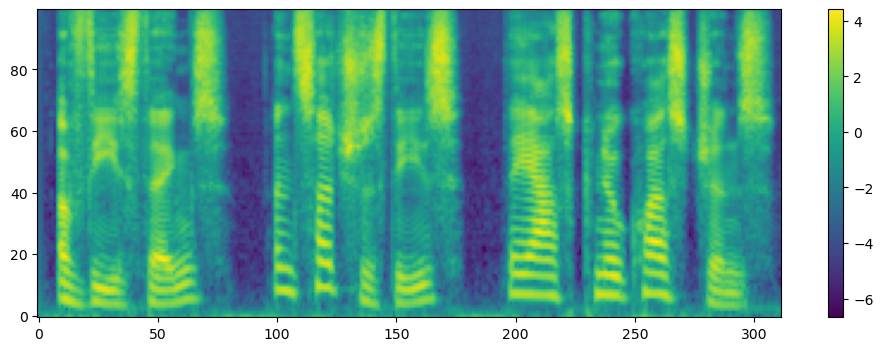

In [8]:
from torchaudio.transforms import MelSpectrogram
from e2_tts_pytorch.e2_tts import log

path = "~/data/LibriTTS_R/dev-clean/174/50561/174_50561_000001_000002"
# path = "~/data/LibriTTS_R/dev-clean/84/121123/84_121123_000008_000000"
audio, sr = torchaudio.load(Path(f"{path}.flac").expanduser())

transform = MelSpectrogram(
    sample_rate = 24_000,
    n_fft = 1024,
    win_length = 1024,
    hop_length = 256,
    n_mels = 100,
    power = 1,
    center = True,
)

original_mel_spec = log(transform(audio)).squeeze(0)
print(f"original_mel_spec: {original_mel_spec.shape}")

# mel_spec_2 = torch.load(f"{path}.mel")
# print(f"mel_spec_2: {mel_spec_2.shape}")

mel_spec = rearrange(original_mel_spec, 'd n -> 1 n d')[:, :original_mel_spec.shape[1] // 2, :]
lens = torch.LongTensor([mel_spec.shape[1]])
# mel_spec_padded = torch.concatenate([mel_spec, torch.zeros_like(mel_spec)], dim=1)
print(f"mel_spec: {mel_spec.shape}, lens: {lens}")

text = ((Path(f"{path}.normalized.txt").expanduser().read_text() + ' ') * 1).strip()
print(f"text: {text}")

phones = Path(f"{path}.phn.txt").expanduser().read_text().strip()
tokens = tokenize_phonemes(phones).unsqueeze(0)
print(f"tokens: {tokens}")

# visualize the mel spectrogram
plt.figure(figsize=(12, 4))
plt.imshow(original_mel_spec.numpy(), origin='lower', aspect='auto')
plt.colorbar()
plt.show()

with torch.inference_mode():
    generated = e2tts.sample(
        cond = mel_spec,
        text = tokens,
        duration = mel_spec.shape[1] * 2,
        steps = 32,
        cfg_strength = 0.0
    )
    
    print(f"Generated: {generated.shape}")
    generated_mel_spec = rearrange(generated, '1 n d -> 1 d n')

# generated_mel_spec = generated_mel_spec[:, :, lens[0]:]

# visualize the mel spectrogram
plt.figure(figsize=(12, 4))
plt.imshow(generated_mel_spec[0].numpy(), origin='lower', aspect='auto')
plt.colorbar()
plt.show()

# visualize the mel spectrogram
plt.figure(figsize=(12, 4))
plt.imshow(original_mel_spec.numpy(), origin='lower', aspect='auto')
plt.colorbar()
plt.show()


In [9]:
from IPython.display import Audio

wave = vocos.decode(rearrange(mel_spec, '1 n d -> 1 d n'))
print(f"wave: {wave.shape}")

# generated_mel = rearrange(generated_mel_spec, '1 n d -> 1 d n')
wave2 = vocos.decode(generated_mel_spec)
# wave2 = wave2[:, wave.shape[1]:]
print(f"wave2: {wave2.shape}")

torchaudio.save("original.wav", wave, 24_000)
torchaudio.save("generated.wav", wave2, 24_000)

display(Audio("original.wav"))
display(Audio("generated.wav"))

wave: torch.Size([1, 39680])
wave2: torch.Size([1, 79616])
